# Final Project
## Emergency Department Analytics: From Statistics to Predictive Models

**Estimated time:** 1 hour

## Load dataset

In [1]:
import pandas as pd
df = pd.read_csv("https://statistical-analysis-and-data-modeling-in-healthcare-02a43a.gitlab.io/labs/final-project/ed_project_data.csv")
df.head()

,visit_id,age,triage_level,arrival_hr,ed_los_hours,num_tests_ordered,admitted
0,1,65,High,3,7.39,2,1
1,2,86,Medium,14,3.12,1,1
2,3,43,Medium,18,6.03,3,0
3,4,85,Low,0,2.74,2,1
4,5,41,High,15,9.45,1,0


## ✅ Task 1: Inspect dataset dimensions and column types

Write code that explicitly prints the number of rows and columns in the dataset, followed by code that displays the data type of every column. Your output should clearly show the dataset size and whether each variable is numeric or categorical.

In [2]:
#Basic Inspection and Class Imbalance:
print('Rows, Columns:', df.shape)
print('\nData Types of Columns:', df.dtypes)
print('Class Imbalance', df['admitted'].value_counts(normalize=False))


Rows, Columns: (400, 7)

Data Types of Columns: visit_id               int64
age                    int64
triage_level          object
arrival_hr             int64
ed_los_hours         float64
num_tests_ordered      int64
admitted               int64
dtype: object
Class Imbalance admitted
0    275
1    125
Name: count, dtype: int64


In [3]:
#Basic Inspection
print('Rows, Columns:', df.shape)
print('\nColumn Data Types:')
print(df.dtypes)



Rows, Columns: (400, 7)

Column Data Types:
visit_id               int64
age                    int64
triage_level          object
arrival_hr             int64
ed_los_hours         float64
num_tests_ordered      int64
admitted               int64
dtype: object


In [4]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
print('\nData types of columns:')
print(df.dtypes)
df.describe().T

Number of rows: 400
Number of columns: 7

Data types of columns:
visit_id               int64
age                    int64
triage_level          object
arrival_hr             int64
ed_los_hours         float64
num_tests_ordered      int64
admitted               int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
visit_id,400.0,200.5000,115.614301,1.00,100.7500,200.500,300.25,400.00
age,400.0,53.5525,20.540375,18.00,36.0000,54.000,71.00,89.00
arrival_hr,400.0,11.2725,7.075195,0.00,5.0000,11.000,17.00,23.00
ed_los_hours,400.0,5.0272,3.203119,0.36,2.5075,4.535,6.86,18.59
num_tests_ordered,400.0,3.0450,1.711812,0.00,2.0000,3.000,4.00,9.00
admitted,400.0,0.3125,0.464093,0.00,0.0000,0.000,1.00,1.00


## ✅ Task 2: Summarize ED length of stay

Write code that calculates the mean (average) and the median of the `ed_los_hours` column. Display both values clearly so that they can be compared.

In [5]:
#LOS mean and median
print('Mean LOS in ED:', df['ed_los_hours'].mean())
print('Median LOS in ED:', df['ed_los_hours'].median())


Mean LOS in ED: 5.0272
Median LOS in ED: 4.535


## ✅ Task 3: Compare LOS by admission status

Create a visualization that compares the distribution of emergency department length of stay (`ed_los_hours`) for patients who were admitted versus those who were not. A boxplot or similar comparison plot is expected.

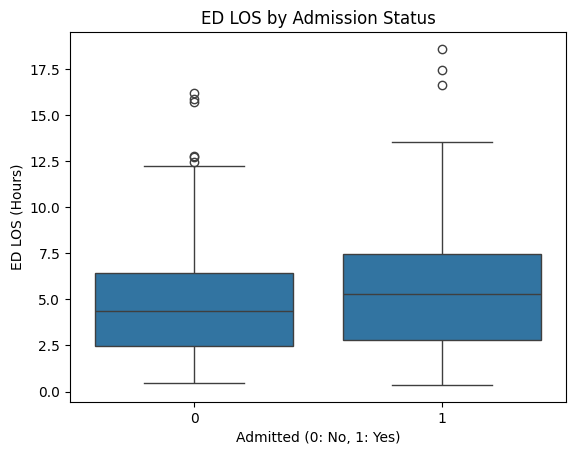

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = 'admitted', y ='ed_los_hours', data=df)
plt.title('ED LOS by Admission Status')
plt.xlabel('Admitted (0: No, 1: Yes)')
plt.ylabel('ED LOS (Hours)')
plt.show()

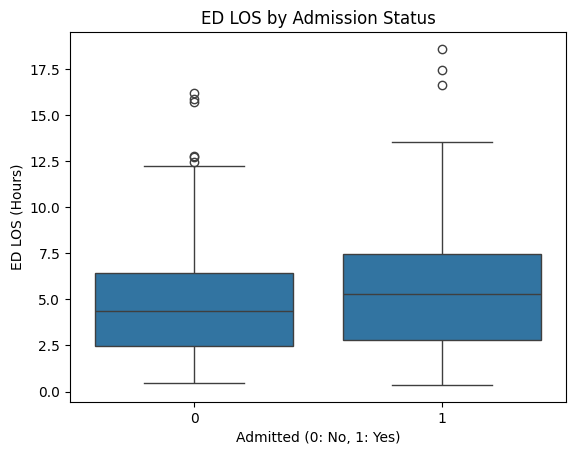

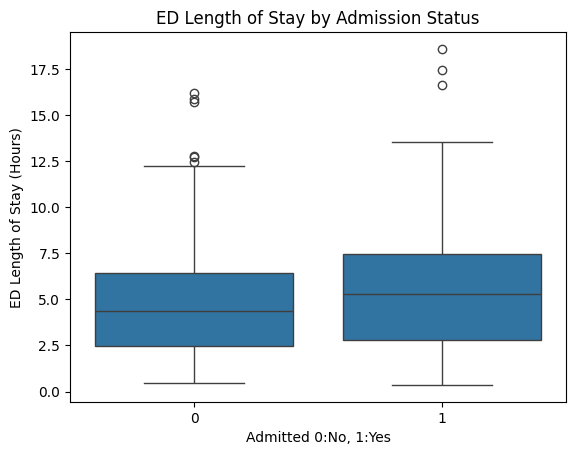

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = 'admitted', y = 'ed_los_hours', data = df)
plt.title('ED LOS by Admission Status')
plt.xlabel('Admitted (0: No, 1: Yes)')
plt.ylabel ('ED LOS (Hours)')
plt.show()

sns.boxplot(x='admitted', y = 'ed_los_hours', data=df )
plt.title('ED Length of Stay by Admission Status')
plt.xlabel('Admitted 0:No, 1:Yes')
plt.ylabel('ED Length of Stay (Hours)')
plt.show()


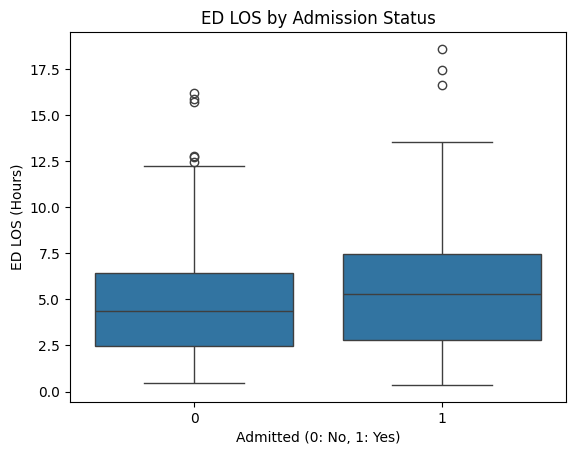

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x ='admitted', y = 'ed_los_hours', data=df)
plt.title('ED LOS by Admission Status')
plt.xlabel('Admitted (0: No, 1: Yes)')
plt.ylabel('ED LOS (Hours)')
plt.show()

## ✅ Task 4: Hypothesis test - Admission versus LOS

Perform an appropriate statistical hypothesis test to determine whether the mean emergency department length of stay differs between admitted and non-admitted patients. Report the test statistic and p-value.

In [13]:
from scipy import stats

# Separate into admitted vs. non-admitted groups for comparison:
los_admitted = df[df['admitted'] ==1]['ed_los_hours']
los_nonadmitted =df[df['admitted'] ==0]['ed_los_hours']

# t-test (independent)
t_statistic, p_value = stats.ttest_ind(los_admitted, los_nonadmitted)
print(f"t-statistic: {t_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

t-statistic: 2.070
p-value: 0.039


## ✅ Task 5: ANOVA - LOS across triage levels

Use a one-way ANOVA to test whether the mean emergency department length of stay differs across the Low, Medium, and High triage categories. Output the F-statistic and p-value.

In [12]:
from scipy.stats import f_oneway

#Separate LOS by triage level
los_low = df[df['triage_level']=='Low']['ed_los_hours']
los_medium = df[df['triage_level']=='Medium']['ed_los_hours']
los_high = df[df['triage_level']=='High']['ed_los_hours']

#One-Way ANOVA
f_statistic, p_value = f_oneway(los_low, los_medium, los_high)
print('One-Way ANOVA:')
print(f"F-statistic: {f_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

One-Way ANOVA:
F-statistic: 0.121
p-value: 0.886


In [11]:
from scipy.stats import f_oneway

#Separate LOS by Triage Level
los_low = df[df['triage_level']=='Low']['ed_los_hours']
los_medium = df[df['triage_level']=='Medium']['ed_los_hours']
los_high = df[df['triage_level']=='High']['ed_los_hours']

#One-Way ANOVA
f_statistic, p_value = f_oneway(los_low, los_medium, los_high)
print('One Way ANOVA:')
print(f"f-statistic: {f_statistic:.3f}")
print(f"p-value: {p_value:.3f}")



One Way ANOVA:
f-statistic: 0.121
p-value: 0.886


In [14]:
from scipy.stats import f_oneway

los_low = df[df['triage_level']=='Low']['ed_los_hours']
los_medium = df[df['triage_level']=='Medium']['ed_los_hours']
los_high = df[df['triage_level']=='High']['ed_los_hours']

f_statistic,p_value= f_oneway(los_low, los_medium, los_high)
print('One Way ANOVA:')
print(f"f-statistic: {f_statistic:.3f}")
print(f"p_value: {p_value:.3f}")

One Way ANOVA:
f-statistic: 0.121
p_value: 0.886


## ✅ Task 6: Logistic regression - Admission risk

Build and train a logistic regression model that predicts the binary `admitted` outcome using `age`, `ed_los_hours`, and `num_tests_ordered` as predictors. Use the variable name logistic_model to refer your model. Print the accuracy of the model using logistic_model.score(X,y).

In [15]:
from sklearn.linear_model import LogisticRegression
X = df[['age', 'ed_los_hours', 'num_tests_ordered']]
y = df['admitted']

logistic_model = LogisticRegression()
logistic_model.fit(X,y)
print(f"Model Accuracy: {logistic_model.score(X, y):.3f}")

Model Accuracy: 0.695


## ✅ Task 7: Evaluate admission model (AUC)

Using the trained logistic regression model created earlier, generate predicted probabilities for admission and compute the ROC–AUC score. Display the numeric AUC value.

In [16]:
from sklearn.metrics import roc_auc_score

y_pred_proba = logistic_model.predict_proba(X)[:,1]
auc_score = roc_auc_score(y, y_pred_proba)
print(f"ROC_AUC Score: {auc_score:.3f}")

ROC_AUC Score: 0.560


In [17]:
from sklearn.metrics import roc_auc_score

y_pred_proba = logistic_model.predict_proba(X)[:,1]
auc_score = roc_auc_score(y, y_pred_proba)
print(f"AUC Score: {auc_score:.3f}")

AUC Score: 0.560


## ✅ Task 8: Decision tree model

Train a decision tree classification model that predicts the `admitted` outcome using the same predictors as the logistic regression model. Ensure the model is fitted without errors. Use the variable name decision_tree_model to refer your model. Print the accuracy of the model using decision_tree_model.score(X,y).

In [18]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(X,y)
print(f"Model Accuracy: {decision_tree_model.score(X,y):.3f}")

Model Accuracy: 1.000


## ✅ Task 9: Random forest comparison

Train a random forest classifier classification model that predicts the admitted outcome using the same predictors as the logistic regression model. Ensure the model is fitted without errors. Use the variable name random_forest_model to refer your model. Print the accuracy of the model using random_forest_model.score(X,y).

In [19]:
#Random Forest Comparison
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)
random_forest_model.fit(X,y)
print(f"Model Accuracy: {random_forest_model.score(X,y):.3f}")

Model Accuracy: 1.000


## ✅ Task 10: Operational interpretation

Based on your analysis of the ED operation team data which of the following statements/option is correct?

A. Patients with longer emergency department length of stay and a higher number of diagnostic tests have an increased likelihood of hospital admission, suggesting these variables can be used for early risk stratification.

B. Age alone is sufficient to predict hospital admission, and length of stay does not contribute meaningful information beyond patient demographics.

C. Admission decisions appear to be random and cannot be meaningfully predicted using triage level, length of stay, or diagnostic testing data.

D. Statistical tests show no measurable differences in length of stay across patient groups, indicating that predictive modeling is not appropriate for this dataset.

In [ ]:
A.